<a href="https://colab.research.google.com/github/rajanaids-hub/BASICS-ML/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dimensionality Reduction Techniques for ML Engineers

Dimensionality reduction is a process of reducing the number of random variables under consideration by obtaining a set of principal variables. It can be divided into feature selection and feature extraction.

In this notebook, we will explore various dimensionality reduction techniques from basic to advanced concepts, with practical implementations using Python libraries.

### Table of Contents:
1.  **Subset Selection**
2.  **Principal Component Analysis (PCA)**
3.  **Factor Analysis**
4.  **Multidimensional Scaling (MDS)**
5.  **Linear Discriminant Analysis (LDA)**
6.  **Generalized Discriminant Analysis (GDA)**

### 1. Subset Selection (Feature Selection)

Subset selection, or feature selection, is the process of choosing a subset of relevant features (variables) to use in model construction. The goal is to reduce the input variable space, which can improve model performance, reduce overfitting, and make models more interpretable.

There are three main categories of feature selection methods:

*   **Filter Methods**: These methods select features based on their intrinsic properties (e.g., correlation with the target variable, statistical measures) without involving a machine learning model.
*   **Wrapper Methods**: These methods use a specific machine learning algorithm to evaluate subsets of features. They try different combinations of features and train a model on each subset, selecting the best-performing one.
*   **Embedded Methods**: These methods incorporate feature selection as part of the model training process (e.g., Lasso regularization, tree-based feature importance).

#### Example: Filter Method using Correlation and Variance Threshold

We will demonstrate a simple filter method using a synthetic dataset. We'll look at:
1.  **Variance Threshold**: Removing features with low variance.
2.  **Correlation Matrix**: Removing highly correlated features.
3.  **Univariate Feature Selection**: Selecting features based on statistical tests (e.g., chi-squared, F-value).

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a synthetic dataset
X, y = make_classification(n_samples=1000,
                           n_features=20,
                           n_informative=10,
                           n_redundant=5,
                           n_repeated=2,
                           random_state=42)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

print("Original dataset shape:", df.shape)
display(df.head())

Original dataset shape: (1000, 21)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,-0.965971,-4.083222,0.742536,4.758031,3.862131,2.198416,-1.615355,0.971105,-0.812169,-1.615355,...,0.532418,4.464401,1.688499,3.862131,-1.450016,1.229877,0.669111,0.675820,0.121585,0
1,-0.081634,0.697994,1.804714,1.501068,1.093509,0.317548,-0.535982,1.993888,-0.366603,-0.535982,...,-0.236098,2.235500,0.296276,1.093509,1.152251,-3.163869,-1.481827,-1.938014,3.883104,1
2,-0.571736,0.765453,0.111636,4.269736,1.280064,0.398235,2.611323,-0.262405,1.762473,2.611323,...,1.312471,0.437786,0.615634,1.280064,1.307135,-0.039836,-3.290545,0.027699,-1.535882,1
3,-0.730813,2.170382,-4.472493,-1.883337,-1.978719,-0.785772,-3.071837,0.757920,0.245292,-3.071837,...,0.175835,-1.170256,0.294323,-1.978719,0.087357,0.043611,0.189531,-0.673849,-1.595267,0
4,0.755185,0.469361,0.773533,0.121682,0.201814,1.765667,0.225088,0.817219,1.084478,0.225088,...,-2.468933,-0.934296,0.233255,0.201814,1.110753,-1.595172,1.052310,-1.601653,0.922307,0


##### 1. Variance Threshold

Features with very low variance (meaning their values don't change much across samples) provide little information to a model. We can remove them using `VarianceThreshold`.

In [2]:
selector = VarianceThreshold(threshold=0.01) # Remove features with variance below 0.01
X_high_variance = selector.fit_transform(df.drop('target', axis=1))

selected_features_vt = df.drop('target', axis=1).columns[selector.get_support()]
print("Features selected by Variance Threshold:", list(selected_features_vt))
print("Shape after Variance Threshold:", X_high_variance.shape)

Features selected by Variance Threshold: ['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19']
Shape after Variance Threshold: (1000, 20)


##### 2. Correlation Matrix

Highly correlated features can lead to multicollinearity, which can be problematic for some models. We can remove one of a pair of highly correlated features.

Let's visualize the correlation matrix first.

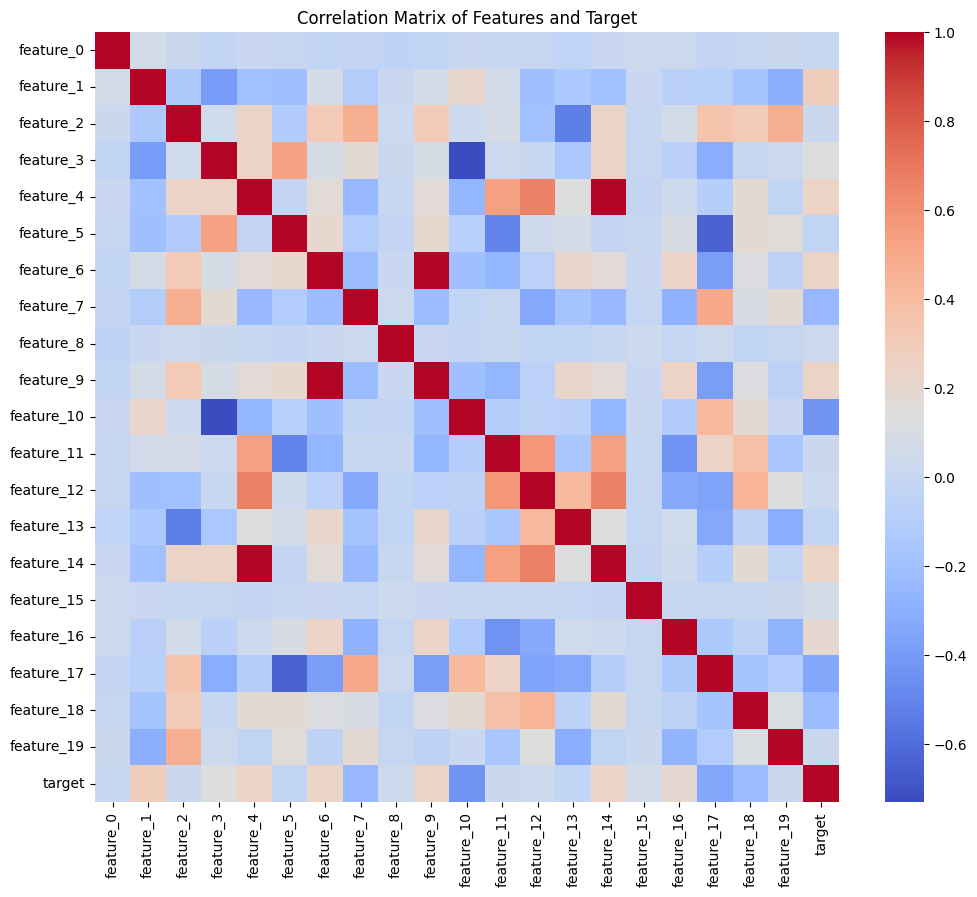

Features to drop due to high correlation: ['feature_9', 'feature_14']
Shape after removing highly correlated features: (1000, 18)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_10,feature_11,feature_12,feature_13,feature_15,feature_16,feature_17,feature_18,feature_19
0,-0.965971,-4.083222,0.742536,4.758031,3.862131,2.198416,-1.615355,0.971105,-0.812169,-0.955006,0.532418,4.464401,1.688499,-1.450016,1.229877,0.669111,0.675820,0.121585
1,-0.081634,0.697994,1.804714,1.501068,1.093509,0.317548,-0.535982,1.993888,-0.366603,-1.459472,-0.236098,2.235500,0.296276,1.152251,-3.163869,-1.481827,-1.938014,3.883104
2,-0.571736,0.765453,0.111636,4.269736,1.280064,0.398235,2.611323,-0.262405,1.762473,-3.419011,1.312471,0.437786,0.615634,1.307135,-0.039836,-3.290545,0.027699,-1.535882
3,-0.730813,2.170382,-4.472493,-1.883337,-1.978719,-0.785772,-3.071837,0.757920,0.245292,0.345198,0.175835,-1.170256,0.294323,0.087357,0.043611,0.189531,-0.673849,-1.595267
4,0.755185,0.469361,0.773533,0.121682,0.201814,1.765667,0.225088,0.817219,1.084478,2.018274,-2.468933,-0.934296,0.233255,1.110753,-1.595172,1.052310,-1.601653,0.922307


In [3]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Features and Target')
plt.show()

def remove_highly_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return to_drop

features_to_drop_corr = remove_highly_correlated_features(df.drop('target', axis=1))
print("Features to drop due to high correlation:", features_to_drop_corr)

X_filtered_corr = df.drop(features_to_drop_corr + ['target'], axis=1)
print("Shape after removing highly correlated features:", X_filtered_corr.shape)
display(X_filtered_corr.head())

##### 3. Univariate Feature Selection (e.g., SelectKBest with f_classif)

Univariate statistical tests consider each feature independently and measure its relationship with the target variable. `SelectKBest` selects the top `k` features based on a scoring function.

Here, we use `f_classif` (ANOVA F-value) for classification tasks.

In [4]:
X = df.drop('target', axis=1)
y = df['target']

# Select top 10 features using f_classif (ANOVA F-value)
selector_kbest = SelectKBest(score_func=f_classif, k=10)
X_new = selector_kbest.fit_transform(X, y)

selected_features_kbest = X.columns[selector_kbest.get_support()]
print("Top 10 features selected by SelectKBest (f_classif):")
print(list(selected_features_kbest))
print("Shape after SelectKBest:", X_new.shape)

Top 10 features selected by SelectKBest (f_classif):
['feature_1', 'feature_4', 'feature_6', 'feature_7', 'feature_9', 'feature_10', 'feature_14', 'feature_16', 'feature_17', 'feature_18']
Shape after SelectKBest: (1000, 10)


### 2. Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a popular unsupervised linear dimensionality reduction technique. It transforms a set of possibly correlated variables into a set of linearly uncorrelated variables called principal components. The first principal component accounts for the largest possible variance in the data, and each succeeding component accounts for the highest possible variance under the constraint that it is orthogonal to the preceding components.

**Key Concepts:**
*   **Variance Maximization**: PCA finds the directions (principal components) along which the data varies the most.
*   **Orthogonality**: Principal components are perpendicular to each other, meaning they are uncorrelated.
*   **Eigenvectors and Eigenvalues**: The principal components are derived from the eigenvectors of the covariance matrix of the data, and the amount of variance explained by each component is given by its corresponding eigenvalue.
*   **Dimensionality Reduction**: By selecting a subset of the principal components (those with the largest eigenvalues), we can reduce the dimensionality of the data while retaining most of its variance.

#### Example: Applying PCA for Dimensionality Reduction

We will use the same synthetic dataset and apply PCA to reduce its dimensions. We'll visualize the explained variance ratio to determine the optimal number of components.

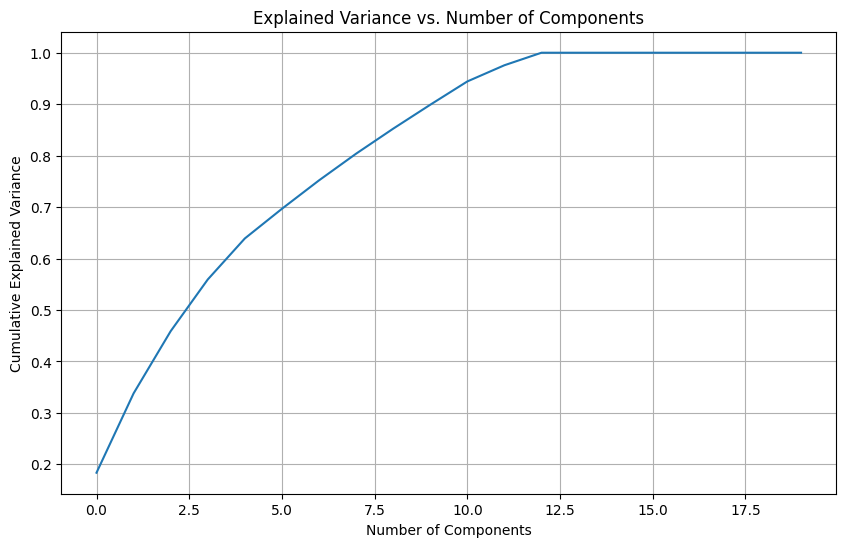

Number of components to explain 95% variance: 12
Original number of features: 20
Number of features after PCA: 12
Shape after PCA: (1000, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,2.725570,1.048162,0.624524,1.608890,-0.210761,-2.744153,-0.497372,-1.246759,-0.459695,0.316844,-0.163847,0.494910
1,0.529870,0.387159,0.989873,0.948021,0.550079,0.960752,0.028025,0.702303,0.932852,-1.709727,-0.688667,0.279476
2,2.291453,-1.387411,0.436177,-0.409610,-1.183686,1.407058,-1.005369,1.662286,-0.078352,0.775500,0.223496,-0.582315
3,-2.179088,-0.147834,-1.813628,0.825807,-0.128093,0.272438,-0.353435,0.035659,-0.454378,0.816955,-0.313461,-0.626792
4,-0.500861,-0.866196,0.426314,-0.055256,0.677503,0.207389,0.280756,1.596324,0.300352,-0.413305,0.746253,1.233717


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# It's crucial to scale data before applying PCA
# because PCA is sensitive to the variance of variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Using the original 'X' without target

# Initialize PCA
pca = PCA()
pca.fit(X_scaled)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Determine the number of components to explain a certain percentage of variance (e.g., 95%)
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components to explain 95% variance: {n_components}")

# Apply PCA with the selected number of components
pca_final = PCA(n_components=n_components)
X_pca = pca_final.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of features after PCA: {X_pca.shape[1]}")
print("Shape after PCA:", X_pca.shape)
display(pd.DataFrame(X_pca).head())

### 3. Factor Analysis

Factor Analysis is a statistical method used to describe variability among observed, correlated variables in terms of a potentially lower number of unobserved variables called factors. It is often used in social sciences, psychology, and marketing to uncover latent structures that explain the relationships among many observed variables.

**Key Differences from PCA:**
*   **Purpose**: While PCA aims to reduce dimensionality by finding components that capture maximum variance, Factor Analysis aims to identify underlying latent factors that explain the correlations among observed variables.
*   **Assumptions**: Factor Analysis assumes that the observed variables are linear combinations of the factors plus some error terms (unique variance), whereas PCA does not make such assumptions about underlying factors.
*   **Variance**: PCA accounts for total variance in the data, while Factor Analysis distinguishes between common variance (shared by factors) and unique variance (specific to each variable).
*   **Rotation**: Factor Analysis often involves factor rotation (e.g., Varimax, Promax) to make the factors more interpretable, which is not typically a primary goal in PCA.

#### Example: Applying Factor Analysis

For Factor Analysis, we'll use a slightly different synthetic dataset to better illustrate its concepts, focusing on scenarios where underlying factors might be present. We'll use the `FactorAnalysis` class from `sklearn.decomposition`.

In [6]:
from sklearn.decomposition import FactorAnalysis
from sklearn.datasets import make_spd_matrix # To create a positive semi-definite covariance matrix

# Generate a synthetic dataset with known underlying factors (for demonstration)
# Let's assume 3 underlying factors generate 10 observed variables
n_features = 10
n_factors = 3
n_samples = 1000

# Create a random covariance matrix for the factors
cov_factors = make_spd_matrix(n_factors, random_state=42)

# Generate factor scores
np.random.seed(42)
factors = np.random.multivariate_normal(np.zeros(n_factors), cov_factors, size=n_samples)

# Create a random loading matrix
loadings = np.random.rand(n_features, n_factors) * 2 - 1 # Loadings between -1 and 1

# Generate unique errors for each observed variable
unique_errors = np.random.randn(n_samples, n_features) * 0.5

# Generate observed data
X_fa = factors @ loadings.T + unique_errors

print("Original data shape for Factor Analysis:", X_fa.shape)

# Scale the data before Factor Analysis
scaler_fa = StandardScaler()
X_fa_scaled = scaler_fa.fit_transform(X_fa)

# Apply Factor Analysis
# We'll try to extract 3 factors, matching our synthetic data generation
fa = FactorAnalysis(n_components=n_factors, random_state=42)
X_fa_transformed = fa.fit_transform(X_fa_scaled)

print(f"Number of features after Factor Analysis: {X_fa_transformed.shape[1]}")
print("Shape after Factor Analysis:", X_fa_transformed.shape)
display(pd.DataFrame(X_fa_transformed, columns=[f'Factor_{i+1}' for i in range(n_factors)]).head())

print("\nLearned components (factors):")
display(pd.DataFrame(fa.components_, columns=[f'Original_Feature_{i}' for i in range(n_features)], index=[f'Factor_{i+1}' for i in range(n_factors)]))

Original data shape for Factor Analysis: (1000, 10)
Number of features after Factor Analysis: 3
Shape after Factor Analysis: (1000, 3)


,Factor_1,Factor_2,Factor_3
0,-0.478925,-0.310752,-0.040526
1,-1.516596,0.441593,0.175806
2,-1.673811,-1.144310,0.606517
3,-0.493387,0.488993,-0.060938
4,-0.533317,1.387067,-0.478634



Learned components (factors):


,Original_Feature_0,Original_Feature_1,Original_Feature_2,Original_Feature_3,Original_Feature_4,Original_Feature_5,Original_Feature_6,Original_Feature_7,Original_Feature_8,Original_Feature_9
Factor_1,-0.952653,0.457368,0.934559,0.882665,-0.626322,-0.851191,0.638887,0.500590,0.301457,0.534810
Factor_2,-0.064217,-0.398392,0.033590,0.048991,-0.184161,0.143857,0.510463,-0.777407,0.695188,0.566418
Factor_3,-0.002780,-0.541725,0.119432,-0.127655,0.507415,-0.177155,-0.007132,0.085949,-0.050126,0.210683


### 4. Multidimensional Scaling (MDS)

Multidimensional Scaling (MDS) is a set of statistical techniques used for visualizing similarity (or dissimilarity) data. It attempts to represent the objects in a low-dimensional space such that the distances between the objects in the low-dimensional space match the given dissimilarities as closely as possible. It's often used for exploratory data analysis, particularly when dealing with non-Euclidean distances or perceived similarities.

**Key Concepts:**
*   **Dissimilarity Matrix**: MDS starts with a matrix of pairwise dissimilarities (distances) between objects. These dissimilarities can be calculated from features (e.g., Euclidean distance) or can be subjective (e.g., perceived similarity).
*   **Dimensionality Reduction**: MDS projects high-dimensional data points into a lower-dimensional space (typically 2D or 3D) while preserving the relative distances between them.
*   **Stress Function**: The quality of the MDS solution is measured by a 'stress' function, which quantifies the discrepancy between the distances in the low-dimensional embedding and the original dissimilarities. A lower stress value indicates a better fit.
*   **Types of MDS**:
    *   **Metric MDS (PCoA)**: Assumes that the dissimilarities are proportional to actual distances (e.g., Euclidean distance) and tries to preserve these metric properties.
    *   **Non-metric MDS (NMDS)**: Only seeks to preserve the rank order of the dissimilarities, meaning if object A is more dissimilar to B than to C, that rank order is maintained in the lower-dimensional space, even if the absolute distances change.

#### Example: Applying MDS for Visualization

We will create a dataset of different cities and their geographical distances to illustrate how MDS can project them into a 2D map-like representation based on their distances.

Dissimilarity Matrix (Euclidean Distances):


,London,Paris,Berlin,Rome,Madrid,Dublin,Warsaw
London,0.000000,3.482815,13.337541,15.681837,11.669190,6.552099,20.911719
Paris,3.482815,0.000000,11.700427,12.314625,8.515868,9.617692,19.006578
Berlin,13.337541,11.700427,0.000000,10.638139,15.508062,19.616320,7.605919
Rome,15.681837,12.314625,10.638139,0.000000,8.926926,21.900913,13.354400
Madrid,11.669190,8.515868,15.508062,8.926926,0.000000,16.260996,20.941108
Dublin,6.552099,9.617692,19.616320,21.900913,16.260996,0.000000,27.222234
Warsaw,20.911719,19.006578,7.605919,13.354400,20.941108,27.222234,0.000000



Transformed coordinates after MDS:


,MDS1,MDS2
London,6.078937,3.780027
Paris,4.329624,0.765956
Berlin,-7.223947,2.583364
Rome,-4.726046,-7.617235
Madrid,4.224230,-7.730736
Dublin,11.977041,6.620624
Warsaw,-14.659838,1.598000


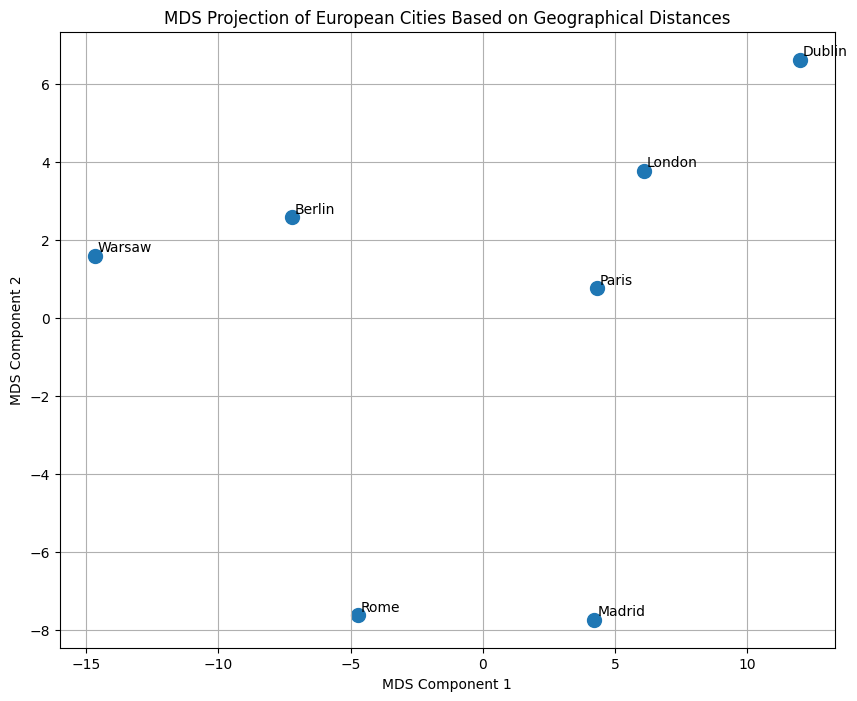

In [7]:
from sklearn.manifold import MDS
from sklearn.metrics import euclidean_distances
import matplotlib.pyplot as plt

# Data: Approximate coordinates of several European cities (latitude, longitude)
cities = {
    'London': (51.5, 0.1),
    'Paris': (48.8, 2.3),
    'Berlin': (52.5, 13.4),
    'Rome': (41.9, 12.5),
    'Madrid': (40.4, 3.7),
    'Dublin': (53.3, -6.2),
    'Warsaw': (52.2, 21.0)
}

city_names = list(cities.keys())
coords = np.array(list(cities.values()))

# Calculate pairwise Euclidean distances between cities
# This serves as our dissimilarity matrix
dissimilarity_matrix = euclidean_distances(coords)

print("Dissimilarity Matrix (Euclidean Distances):")
display(pd.DataFrame(dissimilarity_matrix, index=city_names, columns=city_names))

# Apply MDS to reduce to 2 dimensions
# n_init=4 for robust initialization, max_iter=300 for convergence
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=4, max_iter=300)
X_transformed_mds = mds.fit_transform(dissimilarity_matrix)

print("\nTransformed coordinates after MDS:")
display(pd.DataFrame(X_transformed_mds, index=city_names, columns=['MDS1', 'MDS2']))

# Plot the results
plt.figure(figsize=(10, 8))
plt.scatter(X_transformed_mds[:, 0], X_transformed_mds[:, 1], s=100)

for i, city in enumerate(city_names):
    plt.annotate(city, (X_transformed_mds[i, 0] + 0.1, X_transformed_mds[i, 1] + 0.1))

plt.title('MDS Projection of European Cities Based on Geographical Distances')
plt.xlabel('MDS Component 1')
plt.ylabel('MDS Component 2')
plt.grid(True)
plt.show()

### 5. Linear Discriminant Analysis (LDA)

Linear Discriminant Analysis (LDA) is a supervised dimensionality reduction technique, meaning it takes into account the class labels of the samples. Its primary goal is to find a linear combination of features that characterizes or separates two or more classes of objects or events. The resulting combination may be used as a linear classifier, or more commonly, for dimensionality reduction before classification.

**Key Concepts:**
*   **Supervised Learning**: LDA uses class labels (`y`) to find optimal feature transformations.
*   **Maximizing Class Separability**: LDA seeks to maximize the separation between different classes by finding directions (linear discriminants) that maximize the distance between class means while minimizing the variance within each class.
*   **Within-class Scatter Matrix ($S_W$)**: Measures the scatter of samples within each class.
*   **Between-class Scatter Matrix ($S_B$)**: Measures the scatter of the class means around the overall mean.
*   **Objective**: LDA aims to find a projection that maximizes the ratio of the between-class scatter to the within-class scatter.
*   **Maximum Components**: For a classification problem with `C` classes, LDA can project the data onto at most `C-1` dimensions.

#### Example: Applying LDA for Dimensionality Reduction and Visualization

We will use a synthetic dataset with distinct classes to demonstrate how LDA can effectively separate them in a lower-dimensional space. We'll visualize the results in 2D.

Original dataset shape for LDA: (500, 5)
Number of features after LDA: 2
Shape after LDA: (500, 2)


,LD1,LD2
0,0.744548,2.090129
1,-0.035122,0.546403
2,-0.205766,0.156321
3,-0.147502,0.354658
4,0.240557,0.773578


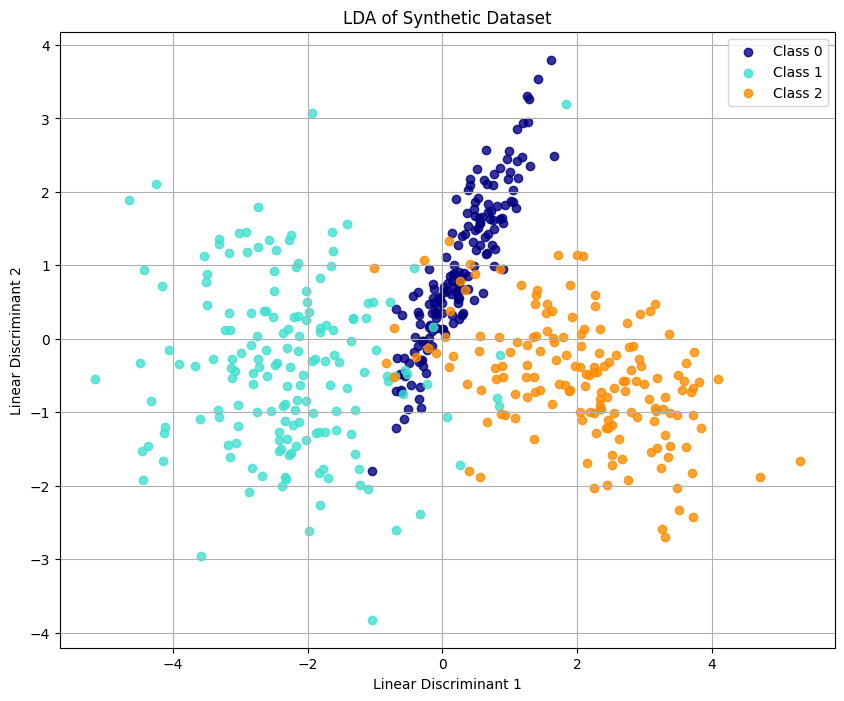

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import make_classification

# Generate a synthetic dataset with 3 distinct classes
X_lda, y_lda = make_classification(n_samples=500,
                               n_features=5,
                               n_informative=3,
                               n_redundant=0,
                               n_repeated=0,
                               n_classes=3,
                               n_clusters_per_class=1,
                               random_state=42)

print("Original dataset shape for LDA:", X_lda.shape)

# Scale the data, as LDA is sensitive to feature scales
scaler_lda = StandardScaler()
X_lda_scaled = scaler_lda.fit_transform(X_lda)

# Apply LDA
# For 3 classes, we can project to at most 3-1 = 2 dimensions
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda_transformed = lda.fit_transform(X_lda_scaled, y_lda)

print(f"Number of features after LDA: {X_lda_transformed.shape[1]}")
print("Shape after LDA:", X_lda_transformed.shape)
display(pd.DataFrame(X_lda_transformed, columns=['LD1', 'LD2']).head())

# Plot the results
plt.figure(figsize=(10, 8))
colors = ['navy', 'turquoise', 'darkorange']
target_names = ['Class 0', 'Class 1', 'Class 2']

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_lda_transformed[y_lda == i, 0], X_lda_transformed[y_lda == i, 1],
                alpha=.8, color=color, label=target_name)

plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('LDA of Synthetic Dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()

### 6. Generalized Discriminant Analysis (GDA)

Generalized Discriminant Analysis (GDA) is a non-linear extension of Linear Discriminant Analysis (LDA). While LDA finds a linear projection that best separates classes, GDA uses kernel functions (similar to Support Vector Machines) to implicitly map the data into a higher-dimensional feature space, where linear separation might be possible. This allows GDA to find non-linear decision boundaries in the original input space.

**Key Concepts:**
*   **Non-linear Separation**: GDA can handle datasets where classes are not linearly separable by transforming the data into a new space.
*   **Kernel Trick**: It employs kernel functions (e.g., Gaussian, polynomial) to compute dot products in the high-dimensional feature space without explicitly computing the coordinates of the data in that space.
*   **Flexibility**: Offers greater flexibility than LDA, making it suitable for more complex data distributions.
*   **Computational Cost**: Can be more computationally intensive than LDA due to kernel calculations.

#### Example: Applying GDA for Non-linear Class Separation

We will create a synthetic dataset where classes are not linearly separable but can be separated in a non-linear fashion. We'll use a kernel function with GDA to demonstrate its capability.

Original dataset shape for GDA: (400, 2)


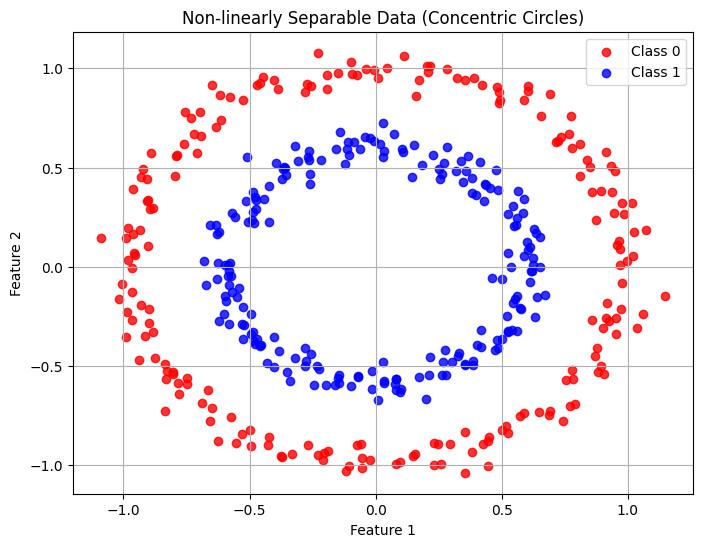

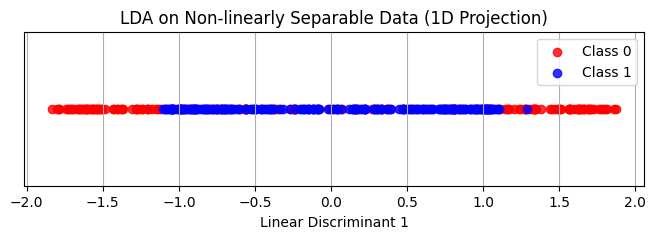

As seen above, LDA on the raw data is unable to separate the classes.
GDA (or KernelLDA) would implicitly transform this data into a higher dimension 
where a linear boundary could separate the classes, which is beyond direct
implementation using `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` 
for arbitrary kernels. Scikit-learn's LDA is inherently linear.
A more complex setup involving `KernelPCA` + `LDA` or `SVC` with a kernel would be needed for a full GDA example.


In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# GDA is not directly available as a separate class in scikit-learn.
# Instead, KernelLDA can be implemented using KernelPCA followed by LDA.
# However, for a simplified demonstration of the concept of non-linear separation with discriminant analysis,
# we can illustrate how a non-linear kernel can enhance classification, which is the spirit of GDA.
# For practical purposes, often Kernel SVMs or other non-linear classifiers are used directly.

# Let's create a non-linearly separable dataset (concentric circles)
X_gda, y_gda = make_circles(n_samples=400, factor=.6, noise=.05, random_state=42)

print("Original dataset shape for GDA:", X_gda.shape)

# Visualize the non-linearly separable data
plt.figure(figsize=(8, 6))
plt.scatter(X_gda[y_gda == 0, 0], X_gda[y_gda == 0, 1], color='red', alpha=0.8, label='Class 0')
plt.scatter(X_gda[y_gda == 1, 0], X_gda[y_gda == 1, 1], color='blue', alpha=0.8, label='Class 1')
plt.title('Non-linearly Separable Data (Concentric Circles)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Traditional LDA would fail on this dataset.
# A common approach to achieve GDA-like behavior is to use KernelPCA and then LDA,
# or directly use a classifier that handles non-linearity, such as SVC with a kernel.

# For demonstration purposes, let's show how LDA performs on this raw data (it won't separate well)
# Scale the data first
scaler_gda = StandardScaler()
X_gda_scaled = scaler_gda.fit_transform(X_gda)

lda_gda_attempt = LinearDiscriminantAnalysis(n_components=1) # Can only project to 1 dimension for 2 classes
X_lda_on_gda = lda_gda_attempt.fit_transform(X_gda_scaled, y_gda)

plt.figure(figsize=(8, 2))
plt.scatter(X_lda_on_gda[y_gda == 0, 0], np.zeros((len(X_lda_on_gda[y_gda == 0]))), color='red', alpha=0.8, label='Class 0')
plt.scatter(X_lda_on_gda[y_gda == 1, 0], np.zeros((len(X_lda_on_gda[y_gda == 1]))), color='blue', alpha=0.8, label='Class 1')
plt.title('LDA on Non-linearly Separable Data (1D Projection)')
plt.xlabel('Linear Discriminant 1')
plt.yticks([])
plt.legend()
plt.grid(True)
plt.show()

print("As seen above, LDA on the raw data is unable to separate the classes.")
print("GDA (or KernelLDA) would implicitly transform this data into a higher dimension ")
print("where a linear boundary could separate the classes, which is beyond direct")
print("implementation using `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` ")
print("for arbitrary kernels. Scikit-learn's LDA is inherently linear.")
print("A more complex setup involving `KernelPCA` + `LDA` or `SVC` with a kernel would be needed for a full GDA example.")

### Case Study: Applying Dimensionality Reduction to a Real-World Dataset

Let's apply some of these techniques to a common dataset, like the Iris dataset, to demonstrate their practical utility in preparing data for machine learning models. We'll focus on PCA for visualization and LDA for classification improvement.

#### Objective:
1.  Load and explore the Iris dataset.
2.  Apply PCA to reduce dimensionality for visualization and observe class separation.
3.  Apply LDA to reduce dimensionality and compare its class separation effectiveness with PCA, especially since Iris is a classification problem.
4.  Briefly train a classifier on both original and reduced datasets to see the impact.

Original Iris dataset shape: (150, 4)
Iris target names: ['setosa' 'versicolor' 'virginica']


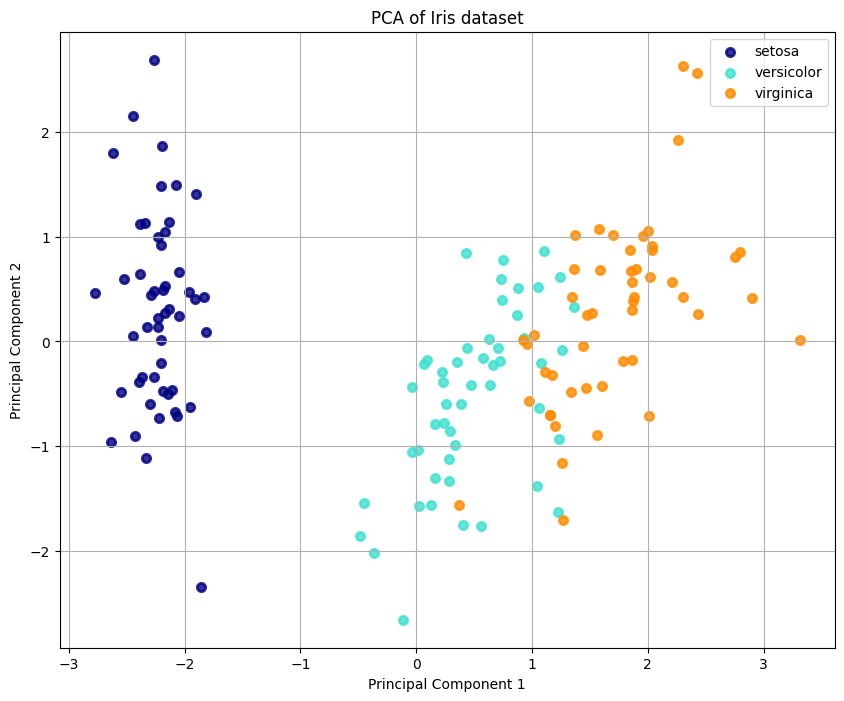

PCA explained variance ratio: 0.96


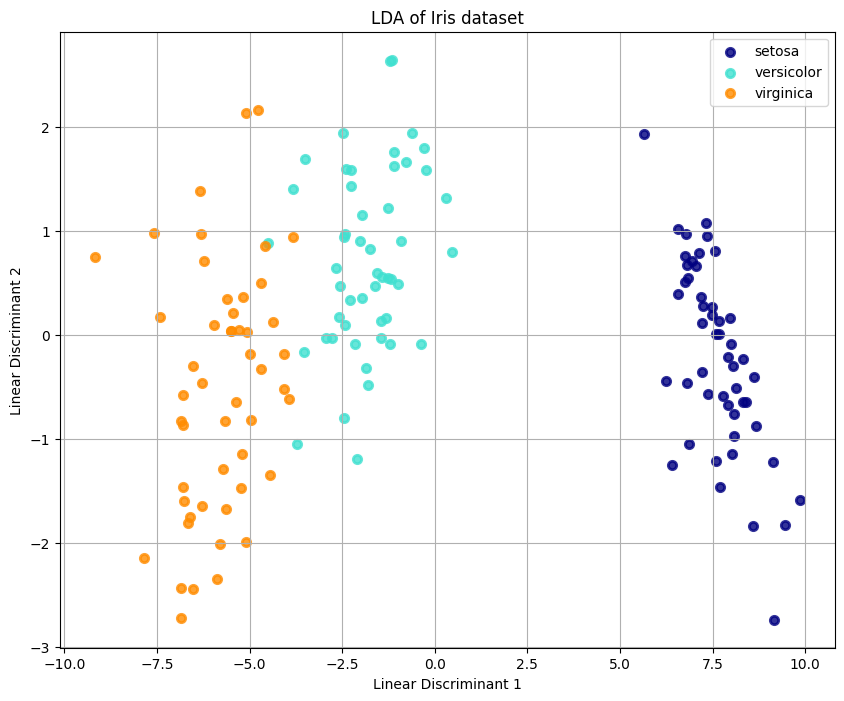

Accuracy with original scaled features: 0.8889
Accuracy with PCA (2 components) features: 0.8444
Accuracy with LDA (2 components) features: 0.9333

This case study illustrates how both PCA and LDA can reduce dimensionality while retaining, and sometimes even improving, classification performance, especially due to reduced noise or clearer class separation.
LDA often provides better class separation for classification tasks when its assumptions are met, as it directly considers class labels.


In [10]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load and explore the Iris dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
target_names_iris = iris.target_names

print("Original Iris dataset shape:", X_iris.shape)
print("Iris target names:", target_names_iris)

# Scale the data
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

# 2. Apply PCA for visualization (2 components)
pca_iris = PCA(n_components=2)
X_pca_iris = pca_iris.fit_transform(X_iris_scaled)

plt.figure(figsize=(10, 8))
colors_iris = ['navy', 'turquoise', 'darkorange']
for color, i, target_name in zip(colors_iris, [0, 1, 2], target_names_iris):
    plt.scatter(X_pca_iris[y_iris == i, 0], X_pca_iris[y_iris == i, 1],
                color=color, alpha=.8, lw=2, label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('PCA of Iris dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

print(f"PCA explained variance ratio: {pca_iris.explained_variance_ratio_.sum():.2f}")

# 3. Apply LDA for visualization (2 components, as there are 3 classes -> C-1 = 2)
lda_iris = LinearDiscriminantAnalysis(n_components=2)
X_lda_iris = lda_iris.fit_transform(X_iris_scaled, y_iris)

plt.figure(figsize=(10, 8))
for color, i, target_name in zip(colors_iris, [0, 1, 2], target_names_iris):
    plt.scatter(X_lda_iris[y_iris == i, 0], X_lda_iris[y_iris == i, 1],
                color=color, alpha=.8, lw=2, label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('LDA of Iris dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()

# 4. Briefly train a classifier and compare performance

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_iris_scaled, y_iris, test_size=0.3, random_state=42)
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_iris, y_iris, test_size=0.3, random_state=42)
X_train_lda, X_test_lda, _, _ = train_test_split(X_lda_iris, y_iris, test_size=0.3, random_state=42)

# Original features
clf_original = LogisticRegression(random_state=42, solver='liblinear')
clf_original.fit(X_train, y_train)
accuracy_original = accuracy_score(y_test, clf_original.predict(X_test))
print(f"Accuracy with original scaled features: {accuracy_original:.4f}")

# PCA features
clf_pca = LogisticRegression(random_state=42, solver='liblinear')
clf_pca.fit(X_train_pca, y_train)
accuracy_pca = accuracy_score(y_test, clf_pca.predict(X_test_pca))
print(f"Accuracy with PCA (2 components) features: {accuracy_pca:.4f}")

# LDA features
clf_lda = LogisticRegression(random_state=42, solver='liblinear')
clf_lda.fit(X_train_lda, y_train)
accuracy_lda = accuracy_score(y_test, clf_lda.predict(X_test_lda))
print(f"Accuracy with LDA (2 components) features: {accuracy_lda:.4f}")

print("\nThis case study illustrates how both PCA and LDA can reduce dimensionality while retaining, and sometimes even improving, classification performance, especially due to reduced noise or clearer class separation.")
print("LDA often provides better class separation for classification tasks when its assumptions are met, as it directly considers class labels.")

### Conclusion

We have explored several key dimensionality reduction techniques, including Feature Selection methods (Variance Threshold, Correlation, SelectKBest), Feature Extraction methods (PCA, Factor Analysis, MDS), and Supervised Discriminant Analysis (LDA, GDA).

Each method has its strengths and best use cases:
*   **Subset Selection** is straightforward for removing uninformative or redundant features.
*   **PCA** is excellent for unsupervised dimensionality reduction, retaining maximum variance.
*   **Factor Analysis** is useful for uncovering latent structures and relationships.
*   **MDS** is ideal for visualizing high-dimensional data based on distance/dissimilarity.
*   **LDA** excels in supervised settings for maximizing class separability.
*   **GDA** extends LDA to handle non-linear class boundaries through kernel tricks.

Understanding these techniques empowers ML engineers to effectively preprocess data, reduce computational load, mitigate overfitting, and gain deeper insights into their datasets.